# LAB 05.02 - Model evaluation

<a target="_blank" href="https://colab.research.google.com/github/rramosp/ai4eng.v1/blob/main/content/LAB%2005.02%20-%20MODEL%20EVALUATION.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()


replicating local resources


In [62]:
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L05.02", varname="student");

logging in as nayibe.velasquez@udea.edu.co... please wait

-------------
using course session ai4eng.v1.udea.r4::2026.1
success!! you are logged in
-------------


## Task 1: Partition randomly `numpy` arrays

observe we can select specific rows and/or columns on a numpy array

In [4]:
import numpy as np

x = np.random.randint(100, size=(20,5))
x[:,0] = range(len(x))
x[0,:] = range(x.shape[1])
x

array([[ 0,  1,  2,  3,  4],
       [ 1, 17, 38, 52, 58],
       [ 2, 96, 59,  7, 49],
       [ 3, 52,  3,  6, 39],
       [ 4, 80,  2, 55, 76],
       [ 5, 45, 88, 82, 63],
       [ 6, 59, 51, 73, 93],
       [ 7, 84, 82, 32, 76],
       [ 8, 86, 24, 29, 41],
       [ 9, 53, 74, 21, 23],
       [10, 63,  5, 98,  4],
       [11, 71,  9, 61, 45],
       [12, 68, 54, 74, 70],
       [13, 38, 47, 47, 16],
       [14, 16, 20, 63, 87],
       [15,  6, 30, 11, 30],
       [16, 97, 45, 67, 85],
       [17,  2,  7, 35, 45],
       [18, 28, 78, 87, 31],
       [19, 25, 84, 79, 54]])

In [5]:
ridxs = np.r_[2,4,5]
x[ridxs]

array([[ 2, 96, 59,  7, 49],
       [ 4, 80,  2, 55, 76],
       [ 5, 45, 88, 82, 63]])

In [6]:
cidxs = np.r_[1,3]
x[:,cidxs]

array([[ 1,  3],
       [17, 52],
       [96,  7],
       [52,  6],
       [80, 55],
       [45, 82],
       [59, 73],
       [84, 32],
       [86, 29],
       [53, 21],
       [63, 98],
       [71, 61],
       [68, 74],
       [38, 47],
       [16, 63],
       [ 6, 11],
       [97, 67],
       [ 2, 35],
       [28, 87],
       [25, 79]])

In [7]:
x[ridxs][:, cidxs]

array([[96,  7],
       [80, 55],
       [45, 82]])

and the dimensions of the array are accessible through `len` and `shape`

In [8]:
len(x), x.shape

(20, (20, 5))

observe also how we can partition it

In [9]:
x[:3]

array([[ 0,  1,  2,  3,  4],
       [ 1, 17, 38, 52, 58],
       [ 2, 96, 59,  7, 49]])

In [10]:
x[3:]

array([[ 3, 52,  3,  6, 39],
       [ 4, 80,  2, 55, 76],
       [ 5, 45, 88, 82, 63],
       [ 6, 59, 51, 73, 93],
       [ 7, 84, 82, 32, 76],
       [ 8, 86, 24, 29, 41],
       [ 9, 53, 74, 21, 23],
       [10, 63,  5, 98,  4],
       [11, 71,  9, 61, 45],
       [12, 68, 54, 74, 70],
       [13, 38, 47, 47, 16],
       [14, 16, 20, 63, 87],
       [15,  6, 30, 11, 30],
       [16, 97, 45, 67, 85],
       [17,  2,  7, 35, 45],
       [18, 28, 78, 87, 31],
       [19, 25, 84, 79, 54]])

we can do the same thing with vectors

In [11]:
v = np.arange(100,120)
v

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119])

In [12]:
v[:5], v[5:]

(array([100, 101, 102, 103, 104]),
 array([105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119]))

finally, observe how we can create a random permutation of a specific vector

In [13]:
np.random.permutation(v)

array([112, 107, 105, 117, 111, 104, 114, 119, 103, 115, 108, 109, 116,
       113, 101, 102, 106, 118, 110, 100])

or the first natural numbers

In [14]:
p = np.random.permutation(20)
p

array([ 8, 14,  2, 18, 15,  3,  1, 13,  0, 17, 19,  9, 10,  6, 11,  7, 16,
        5, 12,  4])

how do you interpret this?

In [15]:
v[p[5:]]

array([103, 101, 113, 100, 117, 119, 109, 110, 106, 111, 107, 116, 105,
       112, 104])

In [16]:
x[p[:5]]

array([[ 8, 86, 24, 29, 41],
       [14, 16, 20, 63, 87],
       [ 2, 96, 59,  7, 49],
       [18, 28, 78, 87, 31],
       [15,  6, 30, 11, 30]])

### assignment

in this task you will have to complete the function  `split_data` below so that:

- it accepts two arguments `X` and `y`, either of which can be any numpy array (1D, 2D, etc.) of the **same** size $n$ (observe the  `assert` statement), and a `pct`
- creates a random permutation of the natural number from $0$ to $n-1$
- partitions the permutations so that the first partition contains the first `n1_elements` $=$ `int(n * pct)` numbers, and the second partition the rest
- interpret the permutation partitions components as indexes to `X` and `y` so that they are partitioned into `X1`, `X2` and `y1`, `y2` respectively

note that **indexes to array** must be of type `int`. do the following to convert a float to int

In [17]:
a,b = 10,.3
c = a*b
print (c)
c = int(c)
print(c)

3.0
3


In [19]:
def split_data(X, y, pct):

    assert len(X)==len(y), "X and y must have the same length"
    assert pct>0 and pct<1, "pct must be in the (0,1) iterval"


    n = len(X)

    permutation = np.random.permutation(n)

    n1_elements = int(n * pct)

    permutation_partition_1 = permutation[:n1_elements]
    permutation_partition_2 = permutation[n1_elements:]

    X1 = X[permutation_partition_1]
    X2 = X[permutation_partition_2]
    y1 = y[permutation_partition_1]
    y2 = y[permutation_partition_2]

    return X1, X2, y1, y2

XX = np.random.randint(100, size=(20,8))
yy = np.arange(100,100+len(XX))

Xtr, Xts, ytr, yts = split_data(XX, yy, pct=.7)

print("X entrenamiento (X1):")
print(Xtr)
print("\ny entrenamiento (y1):")
print(ytr)

X entrenamiento (X1):
[[37 91 58 63  5 79 66  7]
 [ 3  0  1  4 34 83 59  2]
 [15 19  5  9  2 12 59 95]
 [38 50 66  5 34 22  9 34]
 [46 85 99 10 25 94 42 21]
 [49 79 37 47 81 58 29 79]
 [69 56 62 86 52 13 25 44]
 [69 75  7 25 34 90 33 27]
 [32 14 25 48 14 17 64 18]
 [ 0 69  8 74 45 76  4 22]
 [24 96 16 96 70 77 97 56]
 [30 76 12  1 15 73 52 94]
 [11 57  3 17 39 22 25  6]
 [51 54 86 99 15 60 63 44]]

y entrenamiento (y1):
[107 101 117 105 106 102 112 100 119 116 104 110 115 103]


check your solution manually with the following code

In [20]:
XX = np.random.randint(100, size=(20,8))
yy = np.arange(100,100+len(XX))
XX[:,0] = range(len(XX))
XX[0,:] = range(XX.shape[1])
print (XX)
print (yy)

[[ 0  1  2  3  4  5  6  7]
 [ 1 35 38 75 54  8 11 43]
 [ 2 62 99 62 88 22 39 61]
 [ 3 91  5 92  4 47  5 92]
 [ 4 62 29 74 44 66 59 57]
 [ 5 15  7 77 16 23 40 68]
 [ 6 50 90 76 38 56 63 13]
 [ 7 86 47 45 73 85 85 72]
 [ 8  0 17 41 52  0 14 55]
 [ 9 59 83 48 22 52 16 61]
 [10 78 86 95 79 63 82 56]
 [11 84  2 52 35 99 26 54]
 [12 19 89  2 56 44 62 96]
 [13 36 81 26 40 36 14 29]
 [14 88 64 97 50 81 66 64]
 [15 50 77 66 31 37 82 43]
 [16 56 59 66 95 71 84 64]
 [17  8 14 85 18  2 98 54]
 [18  8 98 16 75  4 25 80]
 [19 14 82 28  1 25 82 35]]
[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119]


In [21]:
Xtr, Xts, ytr, yts = split_data(XX, yy, pct=.7)

In [22]:
# check partition ok
np.sum(XX), np.sum(Xtr) + np.sum(Xts), np.sum(yy), np.sum(ytr)+np.sum(yts)

(np.int64(7051), np.int64(7051), np.int64(2190), np.int64(2190))

In [23]:
print (Xtr, "\n--")
print (Xts, "\n--")
print (ytr, "\n--")
print (yts, "\n--")

[[19 14 82 28  1 25 82 35]
 [11 84  2 52 35 99 26 54]
 [ 1 35 38 75 54  8 11 43]
 [15 50 77 66 31 37 82 43]
 [ 0  1  2  3  4  5  6  7]
 [14 88 64 97 50 81 66 64]
 [13 36 81 26 40 36 14 29]
 [ 6 50 90 76 38 56 63 13]
 [ 7 86 47 45 73 85 85 72]
 [16 56 59 66 95 71 84 64]
 [ 8  0 17 41 52  0 14 55]
 [ 3 91  5 92  4 47  5 92]
 [ 2 62 99 62 88 22 39 61]
 [ 4 62 29 74 44 66 59 57]] 
--
[[10 78 86 95 79 63 82 56]
 [12 19 89  2 56 44 62 96]
 [17  8 14 85 18  2 98 54]
 [ 5 15  7 77 16 23 40 68]
 [ 9 59 83 48 22 52 16 61]
 [18  8 98 16 75  4 25 80]] 
--
[119 111 101 115 100 114 113 106 107 116 108 103 102 104] 
--
[110 112 117 105 109 118] 
--


In [24]:
Xts

array([[10, 78, 86, 95, 79, 63, 82, 56],
       [12, 19, 89,  2, 56, 44, 62, 96],
       [17,  8, 14, 85, 18,  2, 98, 54],
       [ 5, 15,  7, 77, 16, 23, 40, 68],
       [ 9, 59, 83, 48, 22, 52, 16, 61],
       [18,  8, 98, 16, 75,  4, 25, 80]])

**submit your code**

In [27]:
student.submit_task(globals(), task_id="task_01");


## Task 2: Fit a model and make predictions

observe how we create new data from synthetic datasets available in `sklearn`

In [28]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from local.lib import mlutils
%matplotlib inline

/content/local/lib/mlutils.py:445: SyntaxWarning: invalid escape sequence '\m'
  time_str = "fit time  (TRAIN)    %.2f $\mu$secs"%(fitting_time*1000)


In [29]:
X, y = make_moons(200, noise=0.2)
X.shape, y.shape

((200, 2), (200,))

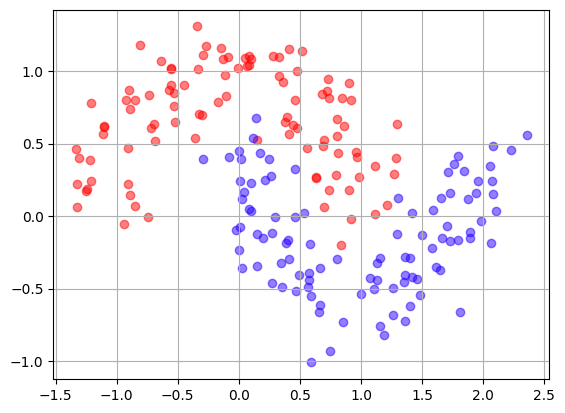

In [30]:
mlutils.plot_2Ddata(X,y); plt.grid();

observe also how we create an algorithm instance and fit a model

(np.float64(0.466675), np.float64(0.533325))

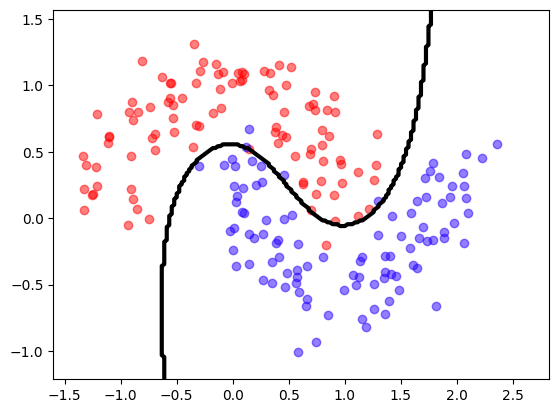

In [31]:
from sklearn.svm import SVC
estimator = SVC(gamma=1)
estimator.fit(X,y)
mlutils.plot_2Ddata_with_boundary(estimator.predict, X, y)

and how we make predictions

In [32]:
preds = estimator.predict(X)
print (preds.shape)
preds

(200,)


array([0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0])

in this task you have to complete the following function so that:

- it makes two non-random partitions of `X` and `y`. One containing the first half of the data and one containing the second part. If the number of elements of `X` is odd, then the second half will contain one more element than the first half.
- it fits the model with the first part of the data
- it makes predictions on the second half of the data
- returns the estimator fitted, and the predictions on the second half of the data.

In [ ]:
def fit_and_predict(estimator, X, y):
    assert len(X)==len(y), "X and y must have the same length"

    predictions = ...

    return estimator, predictions

In [74]:
import numpy as np

def fit_and_predict(estimator, X, y):
    assert len(X) == len(y), "X and y must have the same length"

    # 1. Calculamos el punto de corte para la mitad
    # Al usar // (división entera), si n=21, n_half será 10.
    # La primera mitad será X[:10] y la segunda X[10:], cumpliendo la regla del impar.
    n_half = len(X) // 2

    # 2. Particiones secuenciales (NO aleatorias)
    X_train, y_train = X[:n_half], y[:n_half]
    X_test, y_test   = X[n_half:], y[n_half:]

    # 3. Ajustamos (entrenamos) el modelo con la primera parte
    estimator.fit(X_train, y_train)

    # 4. Realizamos las predicciones sobre la segunda parte
    predictions = estimator.predict(X_test)

    return estimator, predictions

# --- PRUEBA LOCAL ---
from sklearn.linear_model import LogisticRegression

estimator = LogisticRegression()
estimator, preds = fit_and_predict(estimator, X, y)

print("Predicciones obtenidas:")
print(preds)





Predicciones obtenidas:
[0 0 0 0 1 0 1 1 1 0]


check your code. your predictions should be similar to

    preds
    >> array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

In [75]:
X = np.array([[ 0.74799424, -0.5867667 ],
       [-0.64457753,  1.25127894],
       [ 0.53682593,  0.10931563],
       [-0.88825294, -0.06987509],
       [ 0.99612638, -0.52295157],
       [ 1.20586692,  0.01930477],
       [-0.19368482,  0.65121567],
       [ 0.1973759 ,  0.82250723],
       [ 0.94859234, -0.5457241 ],
       [ 1.87967948, -0.22740261],
       [ 0.58766146,  0.3982837 ],
       [ 0.27731571,  1.14369568],
       [-0.67421956,  0.12785382],
       [ 0.56957459,  1.05330376],
       [ 1.52435938, -0.29864338],
       [-0.15973608,  0.21790711],
       [ 1.59037406, -0.56875485],
       [ 0.43257507, -0.48900315],
       [ 1.09440413, -0.73789029],
       [-0.32940869,  0.74671384]])
y = np.array([1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0])
X.shape, y.shape

((20, 2), (20,))

In [76]:
from sklearn.linear_model import LogisticRegression
estimator = LogisticRegression()
estimator, preds = fit_and_predict(estimator, X, y)
preds

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

**submit your code**

In [77]:
student.submit_task(globals(), task_id="task_02");


## Task 3: Select data with indices

Observe how we can create a vector or matrix of `True/False` (boolean) by applying a condition to any matrix or vector

In [78]:
import numpy as np
y = np.random.randint(10, size=15)
print (y)

[3 7 0 1 9 9 0 4 7 3 2 7 2 0 0]


In [79]:
y_less_than_5 = y<5
print (y_less_than_5)

[ True False  True  True False False  True  True False  True  True False
  True  True  True]


and how we can select elements of a vector using a boolean vector of the same length

In [80]:
y[y_less_than_5]

array([3, 0, 1, 0, 4, 3, 2, 2, 0, 0])

In [81]:
y[y<5]

array([3, 0, 1, 0, 4, 3, 2, 2, 0, 0])

python doesn't really care how you construct the vector of booleans to index any other vector or array

In [82]:
v = np.random.randint(20, size=15)
v

array([ 4,  5,  6,  8, 17, 15,  4,  9, 10,  1,  1,  7,  9,  3,  6])

In [83]:
v[y<5]

array([4, 6, 8, 4, 9, 1, 1, 9, 3, 6])

in this task you will complete the function `select_per_class` such that:

- receives an array of data `X` and a vector of labels `y`, of the same length
- the labels `y` are binary, they can only have values `0` or `1`
- makes two partitions of `X`, one corresponding to the places where y is 0, and another where y is 1
- returns the two partitions

For instance, for the following X and y

    X = np.array([[8, 8, 5, 2, 0, 0],
                  [4, 4, 8, 1, 3, 7],
                  [4, 5, 3, 6, 9, 6],
                  [0, 3, 5, 3, 5, 3],
                  [0, 7, 2, 7, 1, 7],
                  [5, 7, 7, 1, 8, 5],
                  [2, 5, 7, 3, 8, 0],
                  [7, 2, 5, 9, 8, 7],
                  [1, 6, 6, 1, 6, 0],
                  [0, 7, 6, 5, 3, 4]])

    y = np.array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

your function must return the following two matrices:

    [[8 8 5 2 0 0]
     [4 4 8 1 3 7]
     [4 5 3 6 9 6]
     [0 3 5 3 5 3]
     [2 5 7 3 8 0]
     [7 2 5 9 8 7]]
     
    [[0 7 2 7 1 7]
     [5 7 7 1 8 5]
     [1 6 6 1 6 0]
     [0 7 6 5 3 4]]


In [84]:
def select_per_class(X, y):
    X1 = X[y == 0]
    X2 = X[y == 1]
    return X1, X2

check manually your code

In [85]:
X = np.array([[8, 8, 5, 2, 0, 0],
              [4, 4, 8, 1, 3, 7],
              [4, 5, 3, 6, 9, 6],
              [0, 3, 5, 3, 5, 3],
              [0, 7, 2, 7, 1, 7],
              [5, 7, 7, 1, 8, 5],
              [2, 5, 7, 3, 8, 0],
              [7, 2, 5, 9, 8, 7],
              [1, 6, 6, 1, 6, 0],
              [0, 7, 6, 5, 3, 4]])

y = np.array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

In [86]:
a,b = select_per_class(X, y)
print (a)
print (b)

[[8 8 5 2 0 0]
 [4 4 8 1 3 7]
 [4 5 3 6 9 6]
 [0 3 5 3 5 3]
 [2 5 7 3 8 0]
 [7 2 5 9 8 7]]
[[0 7 2 7 1 7]
 [5 7 7 1 8 5]
 [1 6 6 1 6 0]
 [0 7 6 5 3 4]]


**submit your code**

In [87]:
student.submit_task(globals(), task_id="task_03");


## Task 4: Measure accuracy

complete the following function such that:

- it receives to binary vectors (composed of 0's and 1's) of the same length
- returns the percentage of elements that are the same in both vectors

recall that

- if `a` and `b` are vectors of the same length a==b   returns a vector of booleans in which positions in True signal that elements in those position are the same
- if `k` is a vector of booleans, `sum(k)` returns the number of `True` elements.


for the following two vectors you should get 0.375

    a = np.array([1,0,0,0,1,1,0,0])
    b = np.array([1,1,1,1,0,1,0,1])
    accuracy(a, b)
    >>> 0.375


In [89]:
def accuracy(y_true, y_pred):
    result = np.sum(y_true == y_pred) / len(y_true)
    return result

In [90]:
a = np.array([1,0,0,0,1,1,0,0])
b = np.array([1,1,1,1,0,1,0,1])
accuracy(a,b)

np.float64(0.375)

**submit your code**

In [91]:
student.submit_task(globals(), task_id="task_04");


## Task 5: Random split, fit and predict

complete the following function so that:

- fits the estimator with a random sample of size `train_pct` of the data `X` and binary labels `y`. You can use the `split_data` function developed previously
- makes predictions on the test part of the data
- measures accuracy of those predictions. you may use the function created previously
- returns the estimator fitted, the test part of `X` and `y`, and the accuracy measured


the execution below should return something with the following structure (the actual numbers will change)


    (LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                        intercept_scaling=1, l1_ratio=None, max_iter=100,
                        multi_class='warn', n_jobs=None, penalty='l2',
                        random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                        warm_start=False), array([[-0.76329684,  0.2572069 ],
            [ 1.02356829,  0.37629873],
            [ 0.32099415,  0.82244488],
            [ 1.08858315, -0.61299904],
            [ 0.58470767,  0.58510559],
            [ 1.60827644, -0.15477173],
            [ 1.53121784,  0.78121504],
            [-0.42734156,  0.87585237],
            [-0.36368682,  0.72152586],
            [ 1.05312619,  0.19835526]]), array([0, 0, 1, 1, 0, 1, 1, 0, 0, 0]), 0.6)

In [ ]:

def split_fit_predict(estimator, X, y, train_pct):

    def split_data(X, y, pct):
        # your code here

    def accuracy(y_true, y_pred):
        # your code here

    Xtr, Xts, ytr, yts = ...
    ... fit the estimator ....
    preds_ts = ... obtain predictions ...
    return estimator, Xts, yts, accuracy(yts, preds_ts)



In [ ]:
from sklearn.linear_model import LogisticRegression

X, y = make_moons(100, noise=0.2)
estimator = LogisticRegression(solver="lbfgs")
split_fit_predict(estimator, X, y, train_pct=0.9)


**submit your code**

In [ ]:
student.submit_task(globals(), task_id="task_05");
